In [1]:
# Check GPU
import torch
print(torch.cuda.is_available())  # Should print True
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
# Training transforms with augmentation
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010)),
])

# Test transforms (no augmentation)
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010)),
])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                              download=True, transform=train_transform)
test_dataset  = torchvision.datasets.CIFAR10(root='./data', train=False,
                                              download=True, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=128, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f"Train batches: {len(train_loader)}, Test batches: {len(test_loader)}")

100%|██████████| 170M/170M [00:13<00:00, 12.5MB/s]


Train batches: 391, Test batches: 79


In [4]:
class PrunableLinear(nn.Module):
    """
    A Linear layer where each weight has a learnable 'gate'.
    gate_scores are passed through Sigmoid → values between 0 and 1.
    pruned_weights = weight * gates  (element-wise)
    If a gate → 0, that weight is effectively removed from the network.
    """
    def __init__(self, in_features, out_features):
        super(PrunableLinear, self).__init__()

        self.in_features  = in_features
        self.out_features = out_features

        # Standard weight and bias — same as nn.Linear
        self.weight = nn.Parameter(torch.Tensor(out_features, in_features))
        self.bias   = nn.Parameter(torch.Tensor(out_features))

        # Gate scores — same shape as weight, also a learnable parameter
        # Initialized to small positive values so gates start near 0.5
        self.gate_scores = nn.Parameter(torch.Tensor(out_features, in_features))

        # Initialize weights properly
        nn.init.kaiming_uniform_(self.weight, a=np.sqrt(5))
        nn.init.zeros_(self.bias)
        # Initialize gate_scores to 0 → sigmoid(0) = 0.5 (neutral start)
        nn.init.zeros_(self.gate_scores)

    def forward(self, x):
        # Step 1: Convert gate_scores to gates using Sigmoid (values 0 to 1)
        gates = torch.sigmoid(self.gate_scores)

        # Step 2: Element-wise multiply weights by gates
        pruned_weights = self.weight * gates

        # Step 3: Standard linear operation with pruned weights
        return nn.functional.linear(x, pruned_weights, self.bias)

    def get_gates(self):
        """Returns the current gate values (after sigmoid)."""
        return torch.sigmoid(self.gate_scores).detach()

    def sparsity(self, threshold=1e-2):
        """Returns fraction of gates below threshold (pruned)."""
        gates = self.get_gates()
        return (gates < threshold).float().mean().item()

In [5]:
class SelfPruningNet(nn.Module):
    def __init__(self, num_classes=10):
        super(SelfPruningNet, self).__init__()

        # Convolutional feature extractor (not prunable — keeps spatial features)
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),   # 16x16
            nn.Dropout2d(0.1),

            # Block 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),   # 8x8
            nn.Dropout2d(0.1),

            # Block 3
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),   # 4x4
        )

        # Classifier using PrunableLinear layers
        self.classifier = nn.Sequential(
            PrunableLinear(256 * 4 * 4, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),

            PrunableLinear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),

            PrunableLinear(512, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = self.classifier(x)
        return x

    def get_all_prunable_layers(self):
        """Returns all PrunableLinear layers in the model."""
        return [m for m in self.modules() if isinstance(m, PrunableLinear)]

    def compute_sparsity_loss(self):
        """L1 norm of all gate values across all PrunableLinear layers."""
        sparsity_loss = 0.0
        for layer in self.get_all_prunable_layers():
            gates = torch.sigmoid(layer.gate_scores)
            sparsity_loss += gates.sum()  # L1 norm (gates are always positive)
        return sparsity_loss

    def report_sparsity(self, threshold=1e-2):
        """Reports sparsity level of the whole network."""
        all_gates = []
        for layer in self.get_all_prunable_layers():
            all_gates.append(layer.get_gates().flatten())
        all_gates = torch.cat(all_gates)
        sparsity = (all_gates < threshold).float().mean().item()
        return sparsity * 100  # as percentage

# Test the model shape
model = SelfPruningNet().to(device)
dummy = torch.randn(4, 3, 32, 32).to(device)
out = model(dummy)
print(f"Output shape: {out.shape}")  # Should be [4, 10]

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

Output shape: torch.Size([4, 10])
Total parameters: 10,599,242


In [6]:
def train_one_epoch(model, loader, optimizer, criterion, lambda_sparse, scheduler=None):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch_idx, (inputs, targets) in enumerate(loader):
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)

        # Classification loss
        cls_loss = criterion(outputs, targets)

        # Sparsity regularization loss (L1 on all gates)
        sparse_loss = model.compute_sparsity_loss()

        # Total loss
        loss = cls_loss + lambda_sparse * sparse_loss

        # Backward pass
        loss.backward()

        # Gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        total_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(targets).sum().item()
        total += targets.size(0)

    acc = 100. * correct / total
    avg_loss = total_loss / len(loader)
    return avg_loss, acc


def evaluate(model, loader, criterion, lambda_sparse):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)

            cls_loss = criterion(outputs, targets)
            sparse_loss = model.compute_sparsity_loss()
            loss = cls_loss + lambda_sparse * sparse_loss

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(targets).sum().item()
            total += targets.size(0)

    acc = 100. * correct / total
    avg_loss = total_loss / len(loader)
    sparsity = model.report_sparsity()
    return avg_loss, acc, sparsity

In [7]:
# Lambda values to compare: low, medium, high
lambda_values = [1e-5, 1e-4, 1e-3]
num_epochs = 50
results = {}  # Store final results for report table

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)  # Label smoothing helps accuracy

for lam in lambda_values:
    print(f"\n{'='*60}")
    print(f"Training with lambda = {lam}")
    print(f"{'='*60}")

    # Fresh model for each lambda
    model = SelfPruningNet().to(device)

    # Optimizer: AdamW with weight decay
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

    # Cosine annealing scheduler for better convergence
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-5)

    best_acc = 0
    best_model_state = None

    for epoch in range(num_epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer,
                                                 criterion, lam, scheduler)
        test_loss, test_acc, sparsity = evaluate(model, test_loader, criterion, lam)
        scheduler.step()

        # Save best model
        if test_acc > best_acc:
            best_acc = test_acc
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}

        if (epoch + 1) % 5 == 0:
            print(f"Epoch [{epoch+1:2d}/{num_epochs}] "
                  f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
                  f"Test Acc: {test_acc:.2f}% | Sparsity: {sparsity:.2f}%")

    # Load best weights and get final stats
    model.load_state_dict(best_model_state)
    _, final_acc, final_sparsity = evaluate(model, test_loader, criterion, lam)

    results[lam] = {
        'accuracy': final_acc,
        'sparsity': final_sparsity,
        'model': model
    }
    print(f"\n✅ Lambda={lam}: Best Test Accuracy = {final_acc:.2f}%, Sparsity = {final_sparsity:.2f}%")


Training with lambda = 1e-05
Epoch [ 5/50] Train Loss: 9.9241 | Train Acc: 78.68% | Test Acc: 82.02% | Sparsity: 0.00%
Epoch [10/50] Train Loss: 4.7259 | Train Acc: 85.87% | Test Acc: 87.48% | Sparsity: 0.00%
Epoch [15/50] Train Loss: 3.0568 | Train Acc: 89.66% | Test Acc: 89.51% | Sparsity: 0.00%
Epoch [20/50] Train Loss: 2.3195 | Train Acc: 92.21% | Test Acc: 91.12% | Sparsity: 0.00%
Epoch [25/50] Train Loss: 1.9310 | Train Acc: 94.11% | Test Acc: 91.26% | Sparsity: 19.02%
Epoch [30/50] Train Loss: 1.7072 | Train Acc: 95.37% | Test Acc: 91.30% | Sparsity: 34.06%
Epoch [35/50] Train Loss: 1.5746 | Train Acc: 96.56% | Test Acc: 92.24% | Sparsity: 41.84%
Epoch [40/50] Train Loss: 1.5019 | Train Acc: 97.16% | Test Acc: 92.29% | Sparsity: 45.78%
Epoch [45/50] Train Loss: 1.4648 | Train Acc: 97.65% | Test Acc: 92.54% | Sparsity: 47.46%
Epoch [50/50] Train Loss: 1.4555 | Train Acc: 97.70% | Test Acc: 92.65% | Sparsity: 47.94%

✅ Lambda=1e-05: Best Test Accuracy = 92.74%, Sparsity = 47.89%


In [8]:
print("\n" + "="*55)
print(f"{'Lambda':<12} {'Test Accuracy (%)':>20} {'Sparsity (%)':>18}")
print("="*55)
for lam, res in results.items():
    print(f"{lam:<12} {res['accuracy']:>20.2f} {res['sparsity']:>18.2f}")
print("="*55)


Lambda          Test Accuracy (%)       Sparsity (%)
1e-05                       92.74              47.89
0.0001                      92.63              95.88
0.001                       92.71              99.96


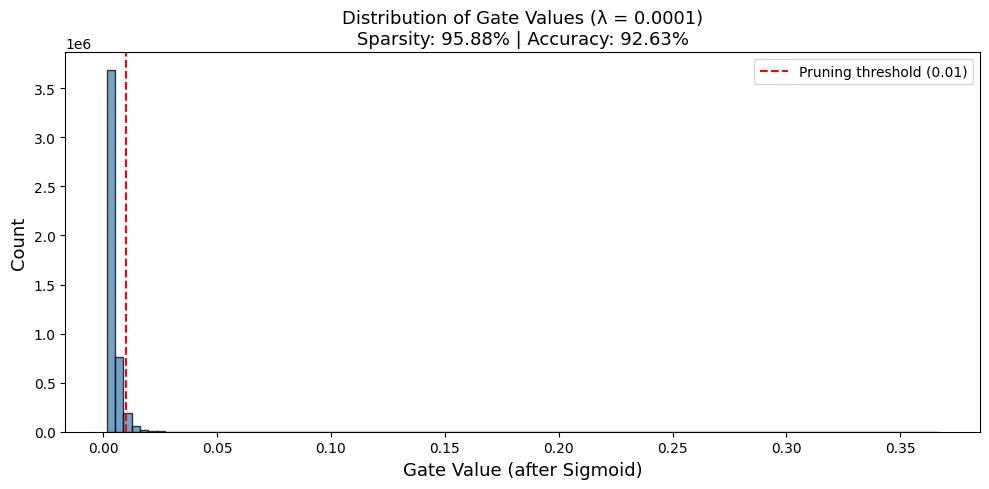

Plot saved as gate_distribution.png


In [9]:
# Use the medium lambda model (or whichever performed best)
best_lambda = 1e-4  # Change this if another lambda gave better accuracy
best_model = results[best_lambda]['model']

# Collect all gate values
all_gates = []
for layer in best_model.get_all_prunable_layers():
    all_gates.append(layer.get_gates().cpu().flatten().numpy())
all_gates = np.concatenate(all_gates)

plt.figure(figsize=(10, 5))
plt.hist(all_gates, bins=100, color='steelblue', edgecolor='black', alpha=0.75)
plt.xlabel('Gate Value (after Sigmoid)', fontsize=13)
plt.ylabel('Count', fontsize=13)
plt.title(f'Distribution of Gate Values (λ = {best_lambda})\n'
          f'Sparsity: {results[best_lambda]["sparsity"]:.2f}% | '
          f'Accuracy: {results[best_lambda]["accuracy"]:.2f}%', fontsize=13)
plt.axvline(x=0.01, color='red', linestyle='--', label='Pruning threshold (0.01)')
plt.legend()
plt.tight_layout()
plt.savefig('gate_distribution.png', dpi=150)
plt.show()
print("Plot saved as gate_distribution.png")